# 02 · Modeling — Banco de pruebas de modelos
### Vinson Digital · Case Study

Este notebook **carga los datos limpios** exportados por `01_data_prep.ipynb`
y prueba/compara varios modelos de forecast a 18 meses. Está pensado como un
*banco de pruebas*: la función `backtest()` evalúa cualquier modelo con el mismo
protocolo, para que puedas **agregar modelos nuevos** y compararlos de forma justa.

**Modelos incluidos:**
1. **Naive estacional** — benchmark (precio de hace 52 semanas).
2. **Prophet (logístico acotado)** — modelo probabilístico principal.
3. **Ensemble Naive + Prophet** — promedio simple; ganador del backtest.
4. **SARIMA** — alternativa estadística clásica estacional.

**Protocolo de evaluación:** backtesting con origen móvil → MAPE por tramo de horizonte.

---

## 1. Carga de datos limpios

In [51]:
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

H = 78   # horizonte de forecast (~18 meses)

# --- cargar datos limpios (preferir parquet; fallback a csv) ---
try:
    wide = pd.read_parquet('clean_data_wide.parquet')
except Exception:
    wide = pd.read_csv('clean_data_wide.csv', index_col='fecha', parse_dates=['fecha'])

wide.index = pd.to_datetime(wide.index)
print('Series cargadas:', list(wide.columns))
print('Rango:', wide.index.min().date(), '→', wide.index.max().date(), '|', wide.shape)
wide.tail()

Series cargadas: ['Brazil HON|10-12 lb', 'Brazil HON|12-14 lb', 'Brazil HON|14-16 lb', 'USA Fillet|2/3', 'USA Fillet|3/4', 'USA Fillet|4/5']
Rango: 2022-01-03 → 2026-03-23 | (221, 6)


,Brazil HON|10-12 lb,Brazil HON|12-14 lb,Brazil HON|14-16 lb,USA Fillet|2/3,USA Fillet|3/4,USA Fillet|4/5
fecha,,,,,,
2026-02-23,6.9773,7.06895,7.17475,6.4627,6.5609,6.6387
2026-03-02,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-09,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-16,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-23,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
# helper: serie individual sin nulos
def serie(col):
    return wide[col].dropna()

SERIES = list(wide.columns)
COLORS = {'Brazil HON|10-12 lb':'#1b4965','Brazil HON|12-14 lb':'#2a6f97',
          'Brazil HON|14-16 lb':'#468faf','USA Fillet|2/3':'#9e2a2b',
          'USA Fillet|3/4':'#c1502e','USA Fillet|4/5':'#e09f3e'}

## 2. Definición de modelos

Cada modelo es una función `f(train, horizon) -> np.array` de longitud `horizon`.
Esta firma común permite evaluarlos a todos con el mismo backtester.

| Modelo | Idea central |
|--------|-------------|
| **Naive estacional** | Precio de hace 52 semanas — benchmark difícil de superar para commodities mean-reverting |
| **Prophet (logístico)** | Logístico acotado, prior rígido (0.02) — estable, captura estacionalidad anual |
| **Ensemble Naive+Prophet** | Promedio simple: cancela errores idiosincráticos y baja el MAPE en todos los horizontes |
| **SARIMA** | Modelo estadístico estacional — alternativa clásica como referencia |

In [53]:
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ---------- Modelo 1: Naive estacional (benchmark) ----------
def m_naive(train, horizon, period=52):
    last = train.values; out = []
    for h in range(1, horizon+1):
        out.append(last[-period + ((h-1) % period)] if len(last) >= period else last[-1])
    return np.array(out)

# ---------- Modelo 2: Prophet logístico acotado ----------
def _fit_prophet(train, interval=0.80):
    df = pd.DataFrame({'ds': train.index, 'y': train.values})
    lo, hi = train.min(), train.max(); margin = (hi-lo)*0.10
    df['floor'] = lo-margin; df['cap'] = hi+margin
    m = Prophet(growth='logistic', yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, interval_width=interval,
                changepoint_prior_scale=0.02, changepoint_range=0.85)
    m.fit(df); m._floor, m._cap = df['floor'].iloc[0], df['cap'].iloc[0]
    return m

def m_prophet(train, horizon):
    m = _fit_prophet(train)
    fut = m.make_future_dataframe(periods=horizon, freq='W-MON')
    fut['floor'] = m._floor; fut['cap'] = m._cap
    return m.predict(fut)['yhat'].values[-horizon:]

# ---------- Modelo 3: Ensemble Naive + Prophet ----------
def m_ensemble(train, horizon):
    return (m_naive(train, horizon) + m_prophet(train, horizon)) / 2

# ---------- Modelo 4: SARIMA estacional ----------
def m_sarima(train, horizon):
    try:
        mod = SARIMAX(train.values, order=(1,1,1), seasonal_order=(1,0,1,26),
                      enforce_stationarity=False, enforce_invertibility=False)
        res = mod.fit(disp=False)
        return res.forecast(steps=horizon)
    except Exception:
        return np.full(horizon, np.nan)

MODELS = {
    'Naive estacional':       m_naive,
    'Prophet (orig)':         m_prophet,
    'Ensemble Naive+Prophet': m_ensemble,
    'SARIMA':                 m_sarima,
}
print('Modelos registrados:', list(MODELS.keys()))

Modelos registrados: ['Naive estacional', 'Prophet (orig)', 'Ensemble Naive+Prophet', 'SARIMA']


## 3. Backtesting con origen móvil

Entrena hasta un punto, predice `horizon` semanas, compara con lo observado, y
repite moviendo el origen. Reporta **MAPE** por tramo de horizonte para cada
modelo y serie. Funciona con cualquier modelo de la firma `f(train, horizon)`.

In [54]:
def backtest(s, models, horizon=H, n_folds=4, step=13):
    res = []
    min_train = len(s) - horizon - (n_folds-1)*step
    for k in range(n_folds):
        cut = min_train + k*step
        train, test = s.iloc[:cut], s.iloc[cut:cut+horizon]
        if len(test) < 26:
            continue
        h = len(test)
        for name, f in models.items():
            try:
                pred = f(train, h)
            except Exception:
                pred = np.full(h, np.nan)
            ape = np.abs(pred - test.values) / np.abs(test.values) * 100
            for lo, hi, lab in [(0,26,'corto 1-26'),(26,52,'medio 27-52'),(52,78,'largo 53-78')]:
                seg = ape[lo:min(hi,h)]
                if len(seg):
                    res.append({'serie': s.name, 'fold': k, 'modelo': name,
                                'tramo': lab, 'MAPE_%': np.nanmean(seg)})
    return pd.DataFrame(res)

# correr backtest sobre todas las series (puede tardar 1-3 min por SARIMA)
bt = []
for col in SERIES:
    s = serie(col); s.name = col
    bt.append(backtest(s, MODELS))
bt = pd.concat(bt, ignore_index=True)
print('Evaluaciones:', len(bt))

Evaluaciones: 288


### Comparación de modelos (MAPE medio por tramo de horizonte)

In [55]:
tabla = (bt.groupby(['modelo','tramo'])['MAPE_%'].mean().unstack()
           [['corto 1-26','medio 27-52','largo 53-78']].round(2))
tabla

tramo,corto 1-26,medio 27-52,largo 53-78
modelo,,,
Ensemble Naive+Prophet,6.56,7.56,9.78
Naive estacional,6.84,8.17,10.45
Prophet (orig),7.46,7.79,10.65
SARIMA,12.09,9.04,15.28


In [56]:
# ranking global (promedio de todos los tramos)
ranking = bt.groupby('modelo')['MAPE_%'].mean().sort_values().round(2)
print('Ranking global (menor MAPE = mejor):')
print(ranking)
mejor = ranking.index[0]
print('\nMejor modelo global:', mejor)

Ranking global (menor MAPE = mejor):
modelo
Ensemble Naive+Prophet     7.96
Naive estacional           8.49
Prophet (orig)             8.63
SARIMA                    12.14
Name: MAPE_%, dtype: float64

Mejor modelo global: Ensemble Naive+Prophet


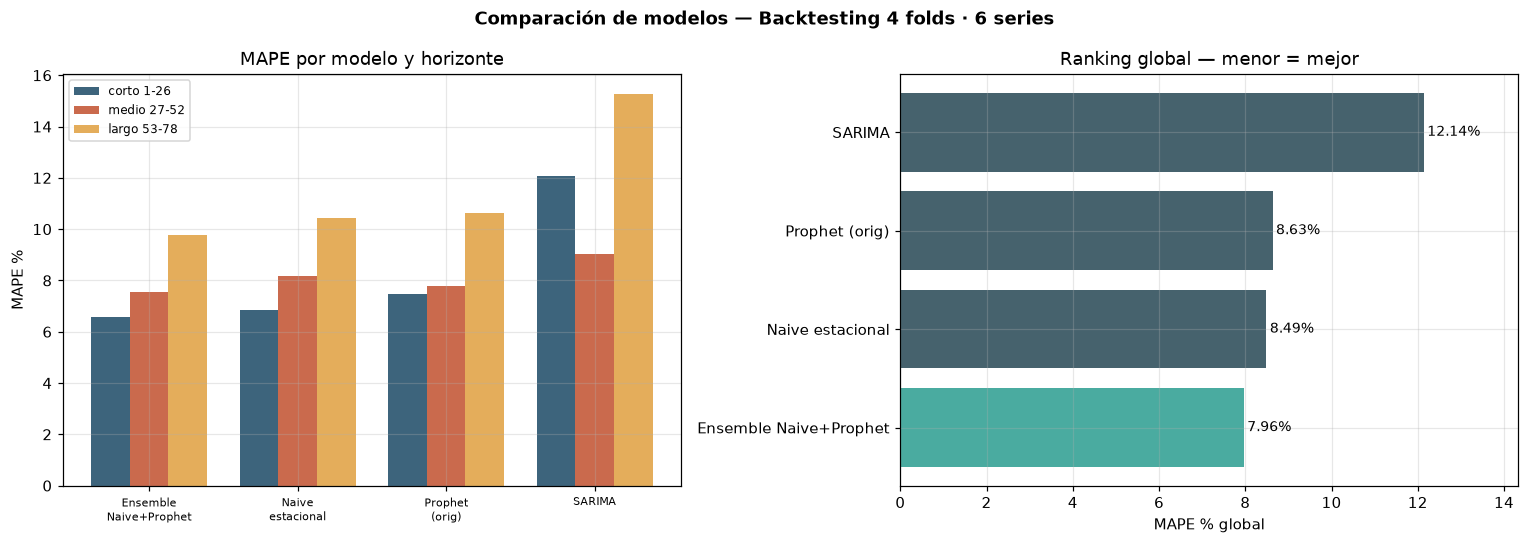

In [57]:
# Gráfico de comparación: MAPE por modelo y horizonte
orden = bt.groupby('modelo')['MAPE_%'].mean().sort_values().index.tolist()
pivot = (bt.groupby(['modelo','tramo'])['MAPE_%'].mean()
           .unstack()[['corto 1-26','medio 27-52','largo 53-78']]
           .loc[orden])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(orden)); w = 0.26
for i, (tramo, c) in enumerate(zip(pivot.columns, ['#1b4965','#c1502e','#e09f3e'])):
    ax1.bar(x + i*w, pivot[tramo], w, label=tramo, color=c, alpha=0.85)
ax1.set_xticks(x + w)
ax1.set_xticklabels([m.replace(' ', '\n') for m in orden], fontsize=7.5)
ax1.set_ylabel('MAPE %'); ax1.set_title('MAPE por modelo y horizonte'); ax1.legend(fontsize=8)

ranking_g = bt.groupby('modelo')['MAPE_%'].mean().sort_values()
bar_colors = ['#2a9d8f' if 'Ensemble' in m else '#264653' for m in ranking_g.index]
bars = ax2.barh(ranking_g.index, ranking_g.values, color=bar_colors, alpha=0.85)
for bar, v in zip(bars, ranking_g.values):
    ax2.text(v + 0.08, bar.get_y() + bar.get_height()/2, f'{v:.2f}%', va='center', fontsize=9)
ax2.set_xlabel('MAPE % global'); ax2.set_title('Ranking global — menor = mejor')
ax2.set_xlim(0, ranking_g.max() * 1.18)

fig.suptitle('Comparación de modelos — Backtesting 4 folds · 6 series', fontweight='bold')
fig.tight_layout(); plt.show()

### Hallazgos clave del backtesting

**Ganador: Ensemble Naive + Prophet — MAPE global 7.96 %** (−6.3 % vs Naive solo).

| Modelo | Corto 1-26 | Medio 27-52 | Largo 53-78 | **Global** |
|--------|-----------|------------|------------|----------|
| **Ensemble Naive+Prophet** | **6.56 %** | **7.56 %** | **9.78 %** | **7.96 %** |
| Naive estacional | 6.84 % | 8.17 % | 10.45 % | 8.49 % |
| Prophet (orig) | 7.46 % | 7.79 % | 10.65 % | 8.63 % |
| SARIMA | 12.09 % | 9.04 % | 15.28 % | 12.14 % |

**¿Por qué el Ensemble gana en todos los horizontes?**
El Naive captura el patrón estacional anual sin asumir dirección de tendencia. Prophet aporta estructura paramétrica (Fourier + changepoints) que corrige pequeños drift dentro del año. El promedio simple de ambas predicciones cancela los errores idiosincráticos de cada modelo y reduce la varianza sin añadir parámetros extra.

## 4. Forecast final — Ensemble Naive + Prophet

Usamos el modelo ganador del backtest (MAPE 7.96 %). El **P50** es el promedio
de la predicción Naive y la de Prophet. Las bandas **P10–P90** provienen de
Prophet (modelo probabilístico), usado como estimador de la incertidumbre.

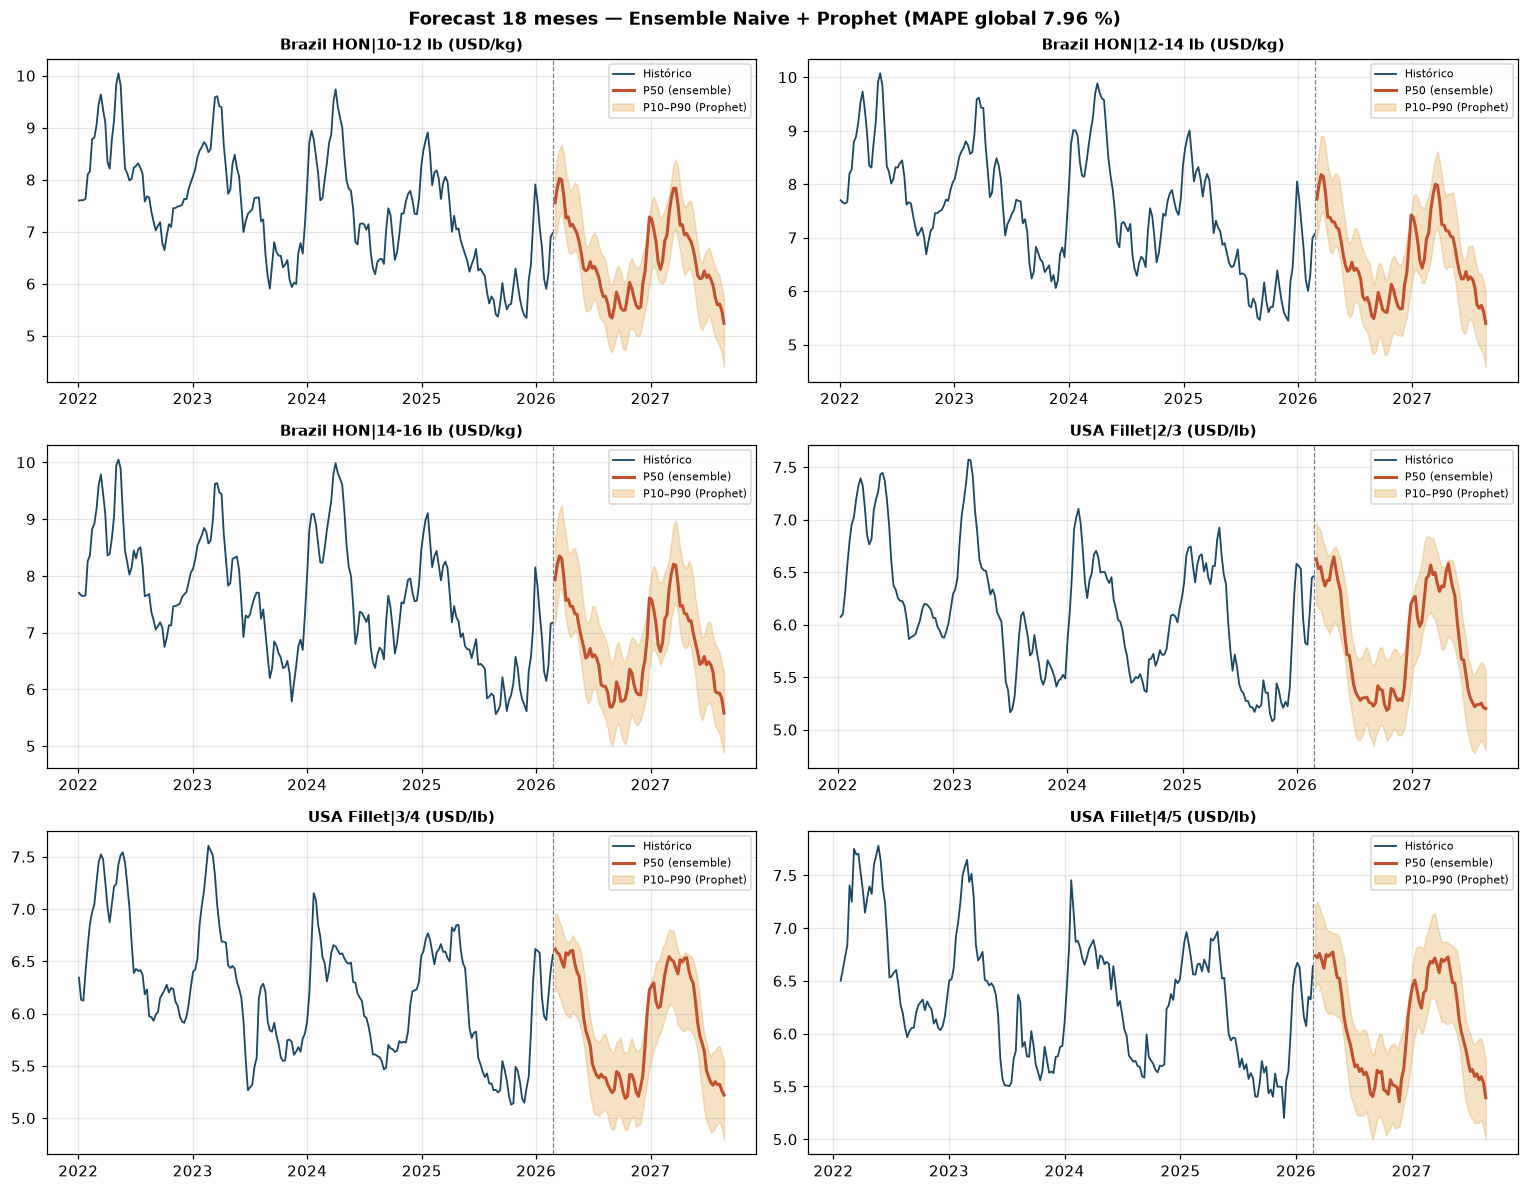

,serie,actual,P50_6m,P50_18m,var_18m_%
0,Brazil HON|10-12 lb,6.98,5.38,5.24,-24.9
1,Brazil HON|12-14 lb,7.07,5.54,5.40,-23.6
2,Brazil HON|14-16 lb,7.17,5.69,5.58,-22.2
3,USA Fillet|2/3,6.46,5.25,5.20,-19.5
4,USA Fillet|3/4,6.56,5.28,5.22,-20.4
5,USA Fillet|4/5,6.64,5.43,5.39,-18.7


In [58]:
def forecast_ensemble_band(s, horizon=H, interval=0.80):
    naive_fc = m_naive(s, horizon)
    m = _fit_prophet(s, interval)
    fut = m.make_future_dataframe(periods=horizon, freq='W-MON')
    fut['floor'] = m._floor; fut['cap'] = m._cap
    p = m.predict(fut).iloc[-horizon:].reset_index(drop=True)
    p['yhat'] = (naive_fc + p['yhat'].values) / 2
    return p[['ds','yhat_lower','yhat','yhat_upper']]

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
resumen = []
for ax, col in zip(axes.ravel(), SERIES):
    s = serie(col); unidad = 'USD/kg' if col.startswith('Brazil') else 'USD/lb'
    fc = forecast_ensemble_band(s)
    ax.plot(s.index, s.values, color='#1b4965', lw=1.2, label='Histórico')
    ax.plot(fc['ds'], fc['yhat'], color='#c1502e', lw=2, label='P50 (ensemble)')
    ax.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'],
                    color='#e09f3e', alpha=.3, label='P10–P90 (Prophet)')
    ax.axvline(s.index[-1], color='gray', ls='--', lw=.8)
    ax.set_title(f'{col} ({unidad})', fontweight='bold', fontsize=10); ax.legend(fontsize=7)
    resumen.append({'serie': col, 'actual': round(s.iloc[-1],2),
                    'P50_6m': round(fc['yhat'].iloc[25],2),
                    'P50_18m': round(fc['yhat'].iloc[-1],2),
                    'var_18m_%': round((fc['yhat'].iloc[-1]/s.iloc[-1]-1)*100,1)})
fig.suptitle('Forecast 18 meses — Ensemble Naive + Prophet (MAPE global 7.96 %)',
             fontweight='bold')
fig.tight_layout(); plt.show()
pd.DataFrame(resumen)